# Sketch-to-Layout: Dataset Preview

This notebook contains code snippets showing how to read the accompanying
datasets from `Sketch-to-Layout: Sketch-Guided Multimodal Layout Generation`
paper.

Heavily inspired by the
[MathWriting example notebook](https://github.com/google-research/google-research/blob/master/mathwriting/mathwriting_code_examples.ipynb).

Licensed under the Apache License, Version 2.0 (Apache 2.0); you may not use
this file except in compliance with the Apache 2.0 license. You may obtain a
copy of the Apache 2.0 license at: https://www.apache.org/licenses/LICENSE-2.0

In [ ]:
# @title Imports

import dataclasses
import os
import pprint
from xml.etree import ElementTree

import matplotlib.pyplot as pl
import numpy as np
import tensorflow as tf

# InkML Asset Primitives

## Download InkML asset primitives

Download the InkML primitives data and unpack it. The ziped archive contains 1024 asset primitives, and is 6.1MB compressed.

In [ ]:
!wget -nc https://storage.mtls.cloud.google.com/sketch_to_layout_dataset/asset_primitives.tgz
!tar zxf asset_primitives.tgz
!ls asset_primitives

ASSET_PRIMITIVES_ROOT_DIR = 'asset_primitives'

## Reading InkML primitives

All inks representing the asset primitives are provided in InkML format. The code below shows how to read the specific structure used by us.

In [ ]:
@dataclasses.dataclass
class Ink:
  """Represents a single ink, as read from an InkML file."""

  # Every stroke in the ink.
  # Each stroke array has shape (3, number of points), where the first
  # dimensions are (x, y, timestamp), in that order.
  strokes: list[np.ndarray]
  # Metadata present in the InkML.
  annotations: dict[str, str]


def read_inkml_file(filename: str) -> Ink:
  """Reads an InkML file and returns an `Ink` representation of its contents."""
  with open(filename, 'r') as f:
    root = ElementTree.fromstring(f.read())

  strokes = []
  annotations = {}

  for element in root:
    tag_name = element.tag.removeprefix('{http://www.w3.org/2003/InkML}')
    if tag_name == 'annotation':
      annotations[element.attrib.get('type')] = element.text

    elif tag_name == 'trace':
      points = element.text.split(',')
      stroke_x, stroke_y, stroke_t = [], [], []
      for point in points:
        x, y, t = point.split(' ')
        stroke_x.append(float(x))
        stroke_y.append(float(y))
        stroke_t.append(float(t))
      strokes.append(np.array((stroke_x, stroke_y, stroke_t)))

  return Ink(strokes=strokes, annotations=annotations)


def display_ink(
    ink: Ink,
    *,
    figsize: tuple[int, int] = (15, 10),
    linewidth: int = 2,
    color=None,
):
  """Displays a single ink on a matplotlib figure."""
  pl.figure(figsize=figsize)
  for stroke in ink.strokes:
    pl.plot(stroke[0], stroke[1], linewidth=linewidth, color=color)
    pl.title(
        f"{ink.annotations.get('sourceDataset', '')} -- "
        f"{ink.annotations.get('sourceKey', '')} -- "
    )
  pl.gca().invert_yaxis()
  pl.gca().axis('equal')

Prints and displays one asset primitive example, from all the examples found in the asset primitives root directory.

{'assetOriginalHeight': '490',
 'assetOriginalWidth': '616',
 'assetType': 'image',
 'sourceDataset': 'slidevqa',
 'sourceKey': 'indias-mobile-commerce-growth-in-2014-12-1024.jpg',
 'split': 'val_test'}


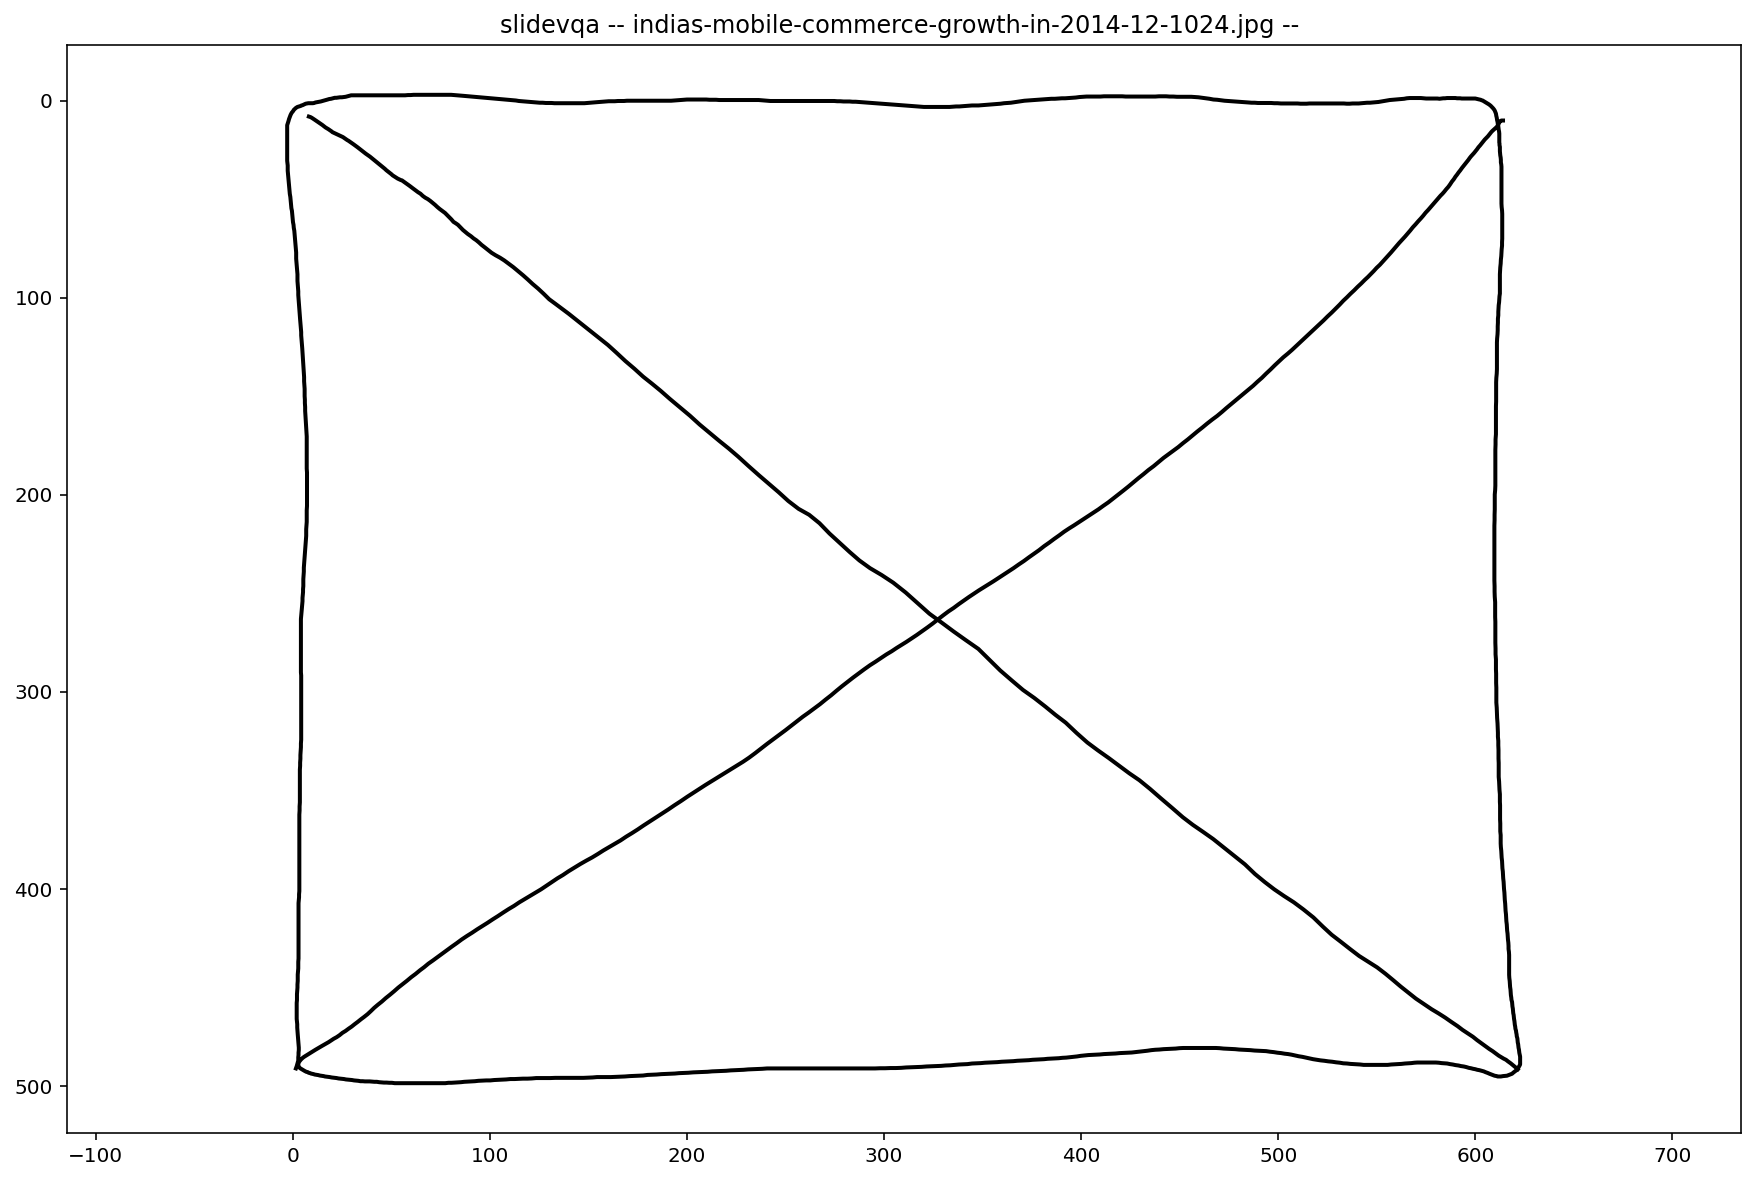

In [ ]:
all_ink_filenames = os.listdir(os.path.join(ASSET_PRIMITIVES_ROOT_DIR, 'data'))
ink = read_inkml_file(
    os.path.join(ASSET_PRIMITIVES_ROOT_DIR, 'data', all_ink_filenames[20])
)
pprint.pprint(ink.annotations)
display_ink(ink, color='black')

# Generated Sketches

We also released the already pre-generated layouts for DocLayNet, PubLayNet and SlideVQA datasets using the asset primitives that we collected.

## Download generated sketches excerpt

Download the generated sketches excerpt data and unpack it. The excerpt contains 15 samples, and is < 1MB compressed.

In [ ]:
!wget -nc https://storage.mtls.cloud.google.com/sketch_to_layout_dataset/generated_sketches_excerpt.tgz
!tar zxf generated_sketches_excerpt.tgz
!ls generated_sketches_excerpt

GENERATED_SKETCHES_EXCERPT_ROOT_DIR = 'generated_sketches_excerpt'

## Reading TFRecord tf.train.Examples

Here is an example code of how the data looks like, and how to visualize it.

In [ ]:
feature_description = {
    'example_id': tf.io.FixedLenFeature([], tf.string, default_value=''),
    'sketch/encoded': tf.io.FixedLenFeature([], tf.string, default_value=''),
}


def _parse_function(example_proto):
  # Parse the input `tf.train.Example` proto using the dictionary above.
  return tf.io.parse_single_example(example_proto, feature_description)


raw_dataset_files = tf.data.Dataset.list_files(
    os.path.join(
        GENERATED_SKETCHES_EXCERPT_ROOT_DIR,
        'generated_sketches_excerpt.tfrecord*',
    ),
    shuffle=False,
)

raw_dataset = raw_dataset_files.flat_map(tf.data.TFRecordDataset)
parsed_dataset = raw_dataset.map(_parse_function)

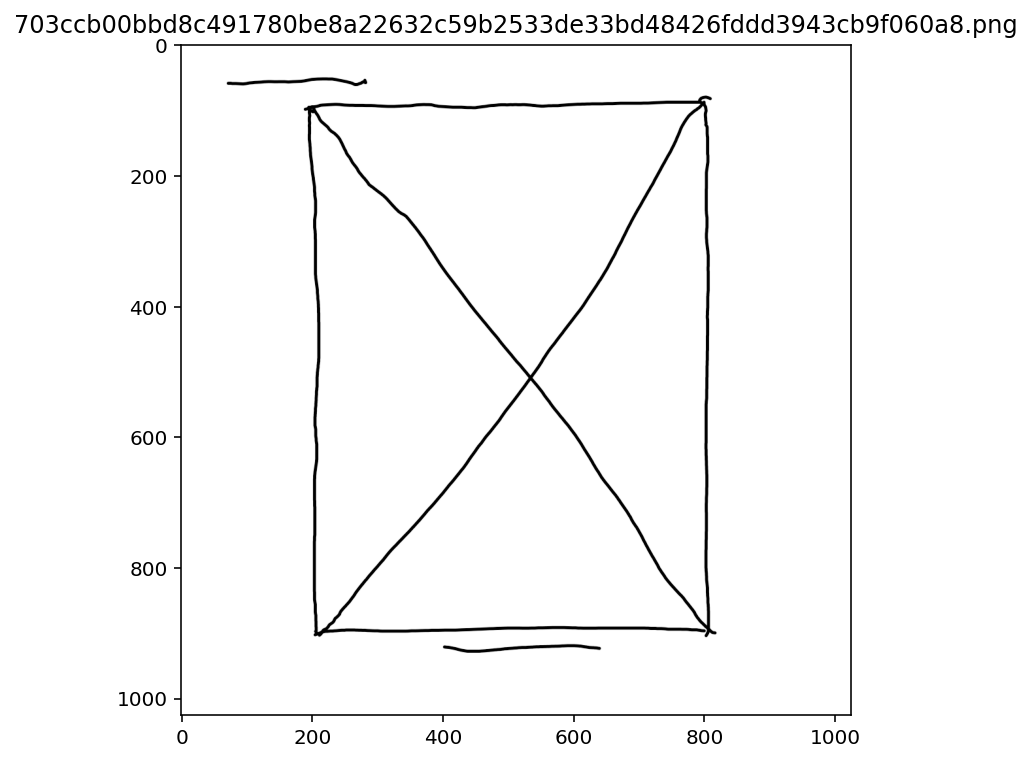

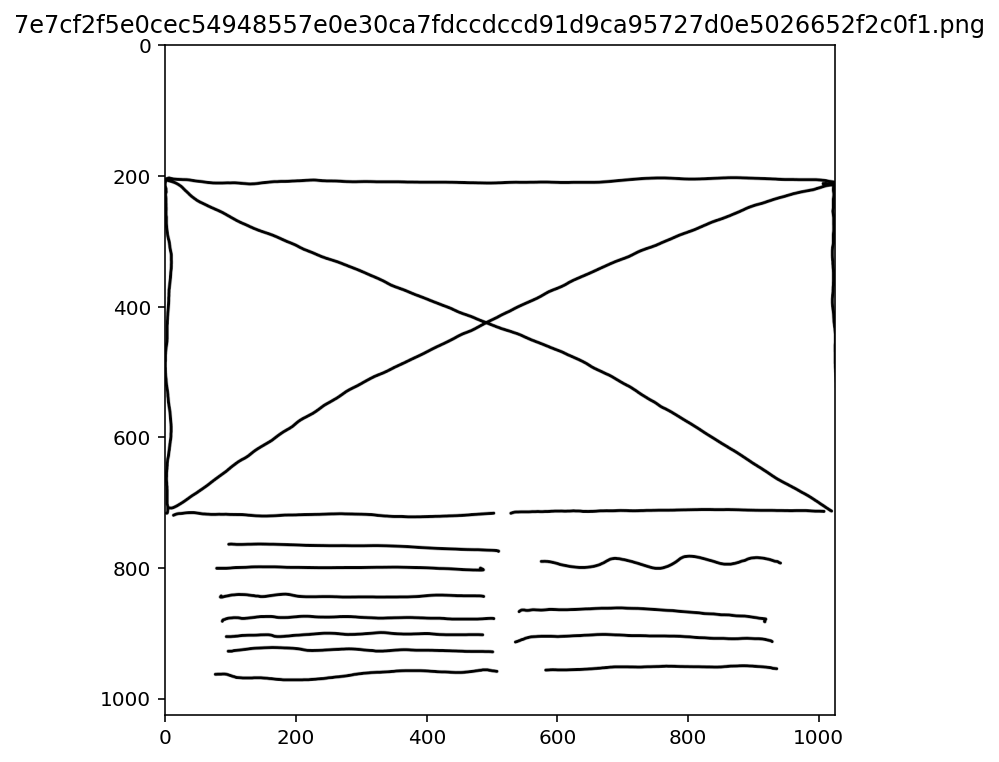

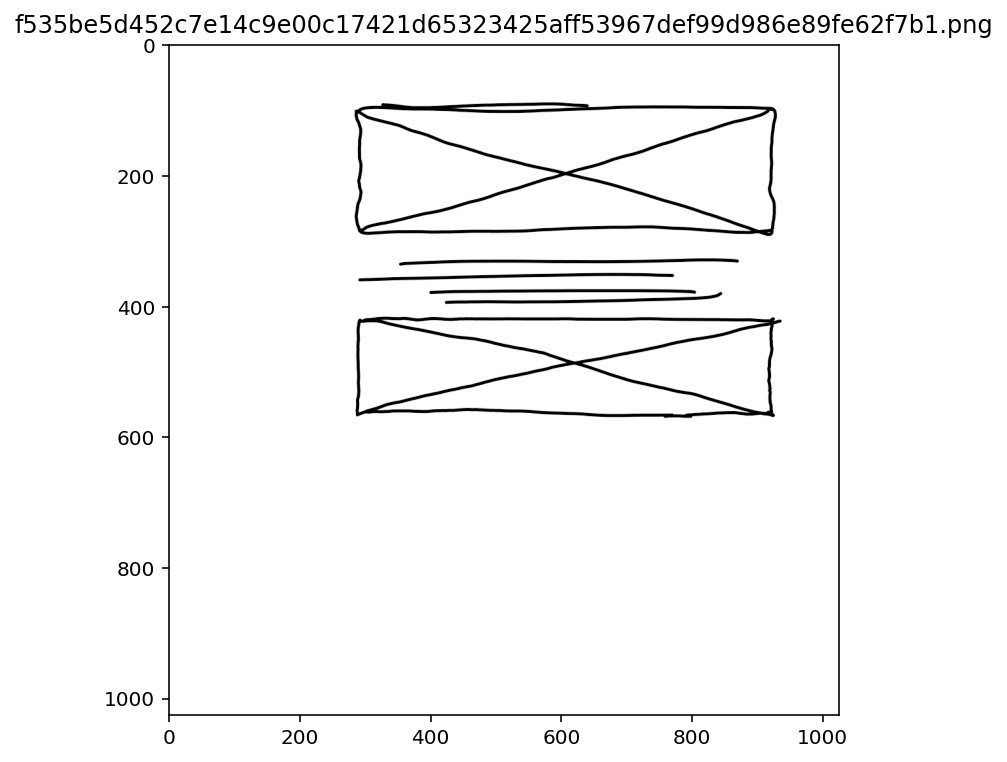

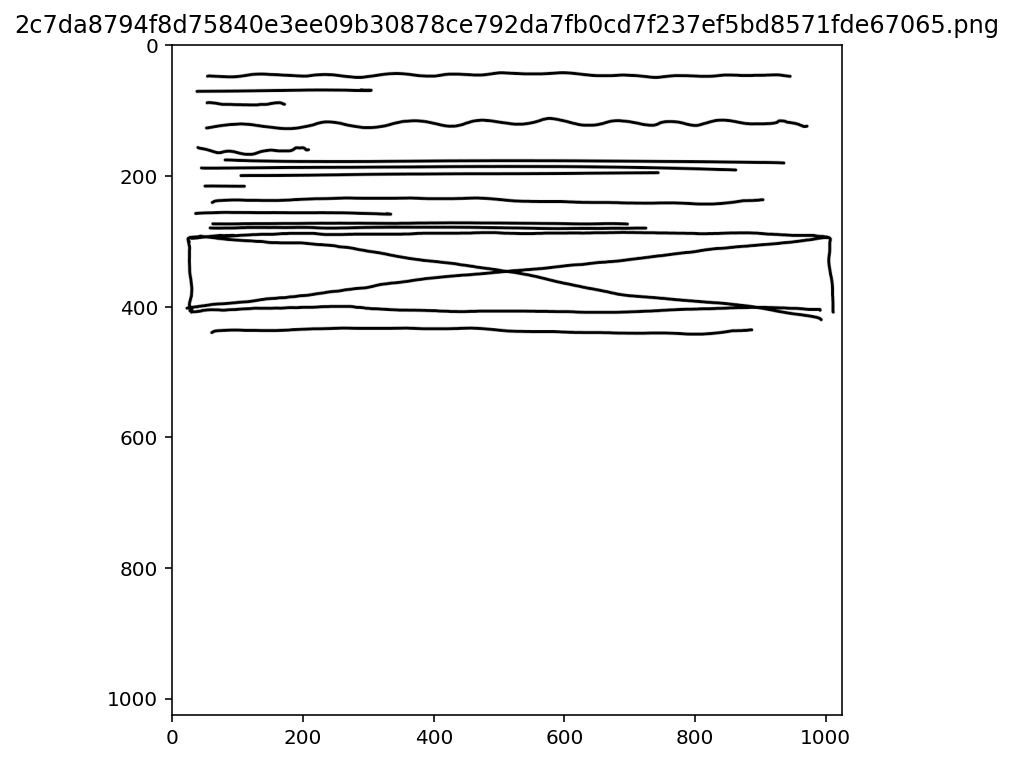

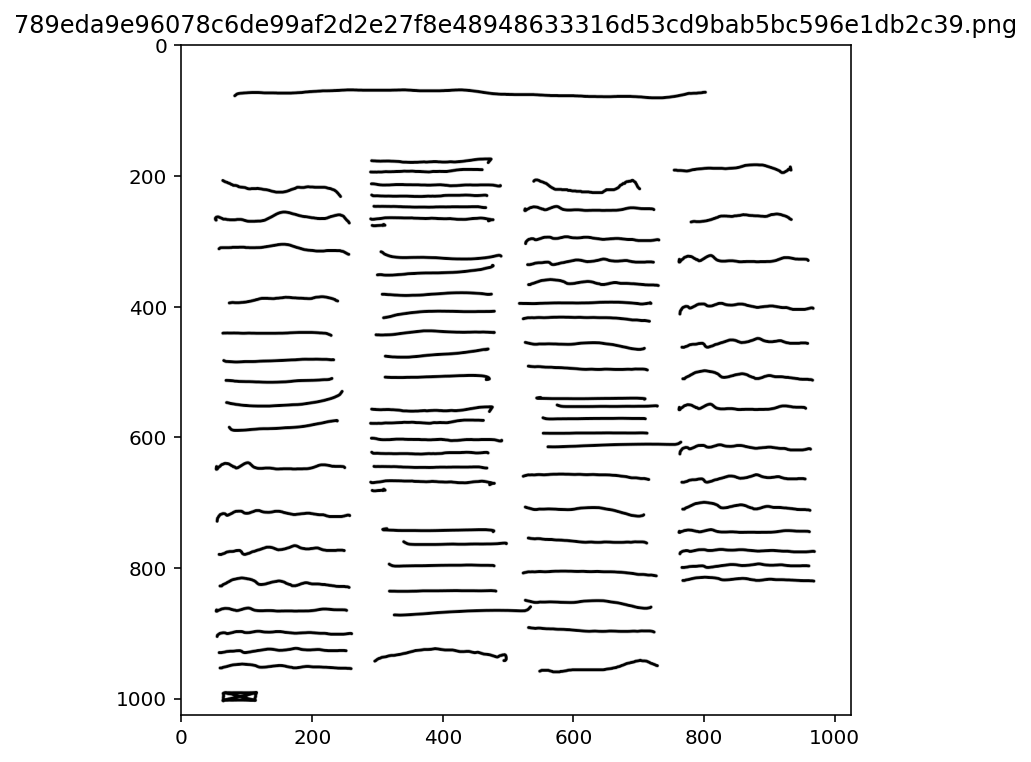

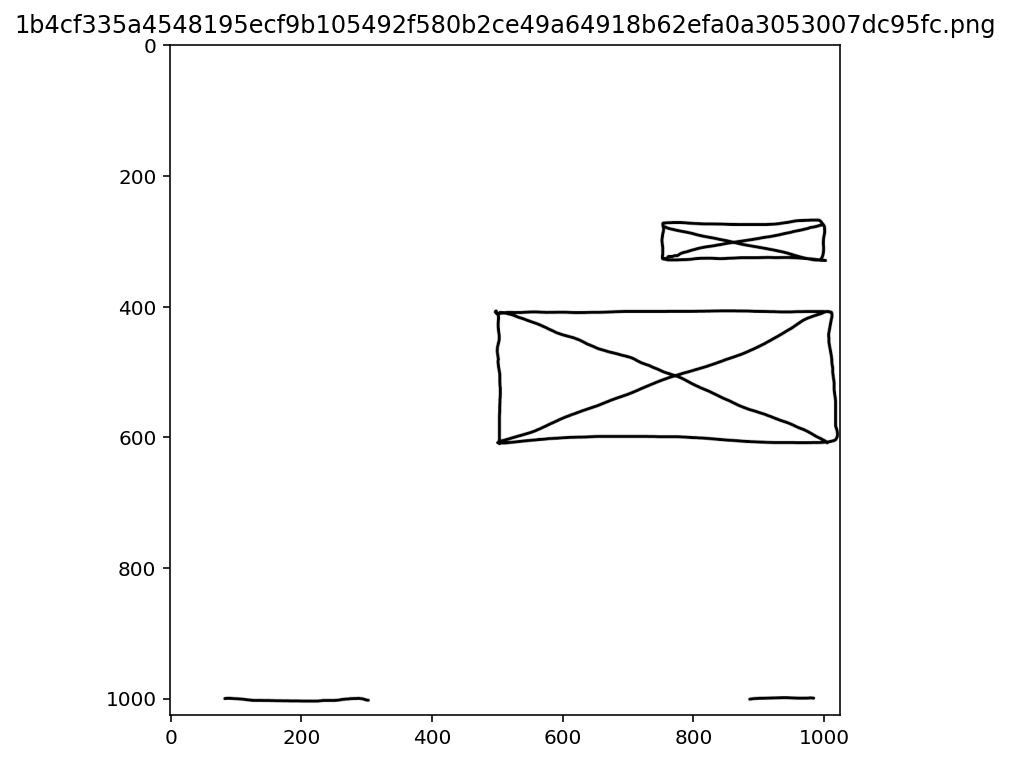

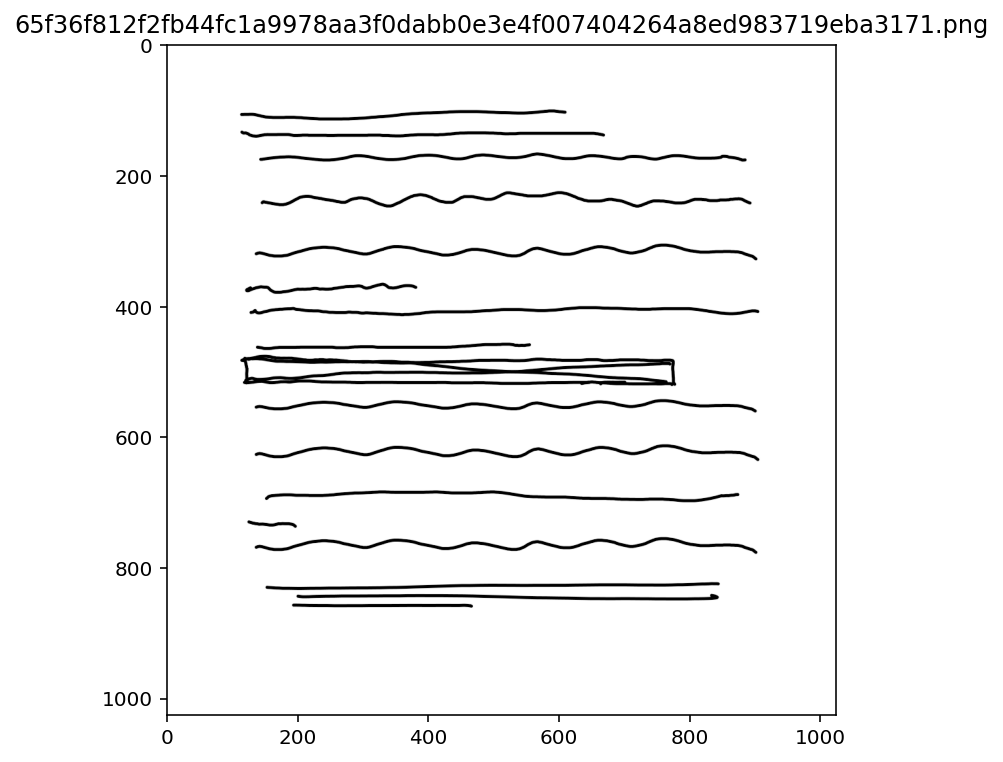

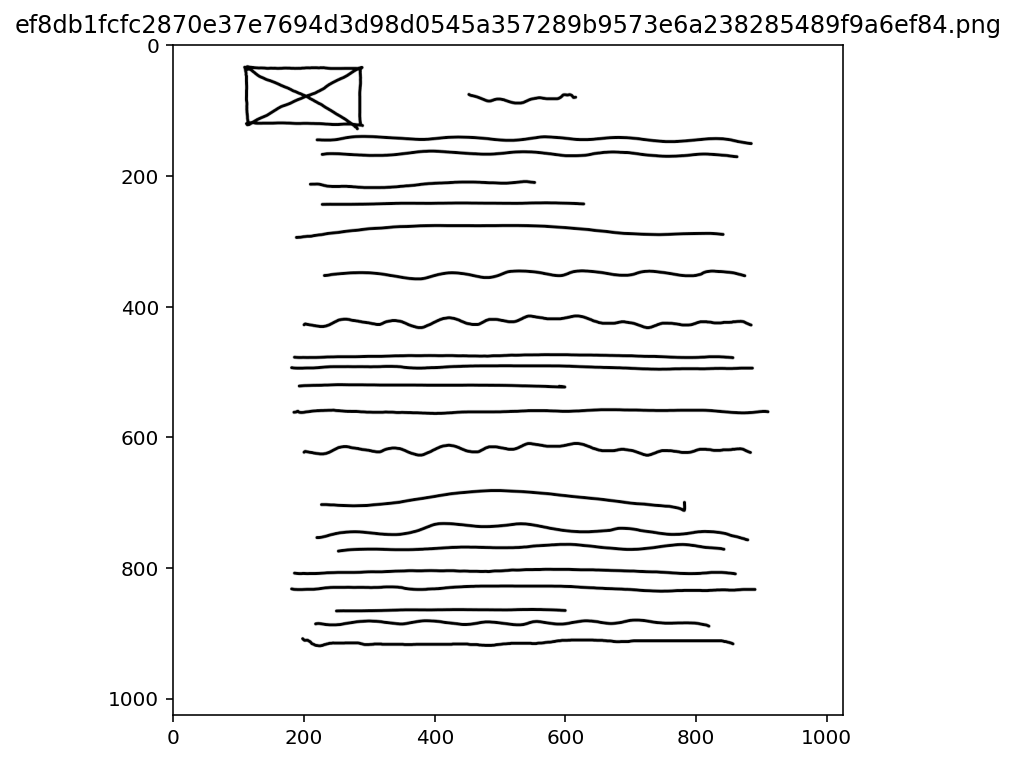

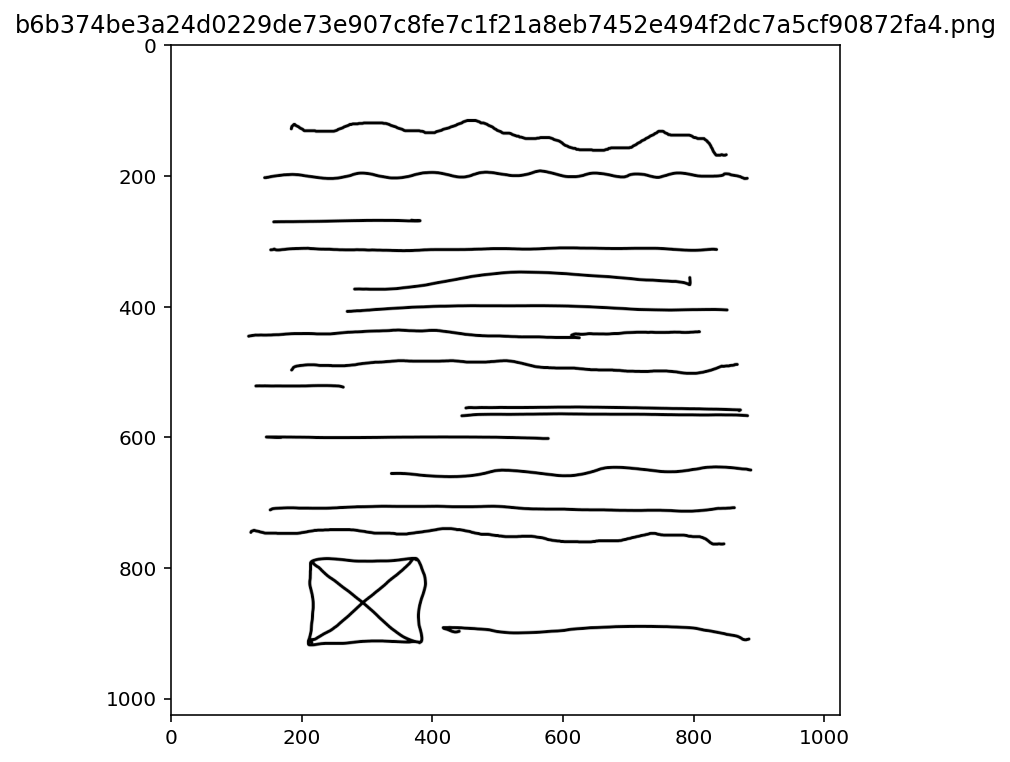

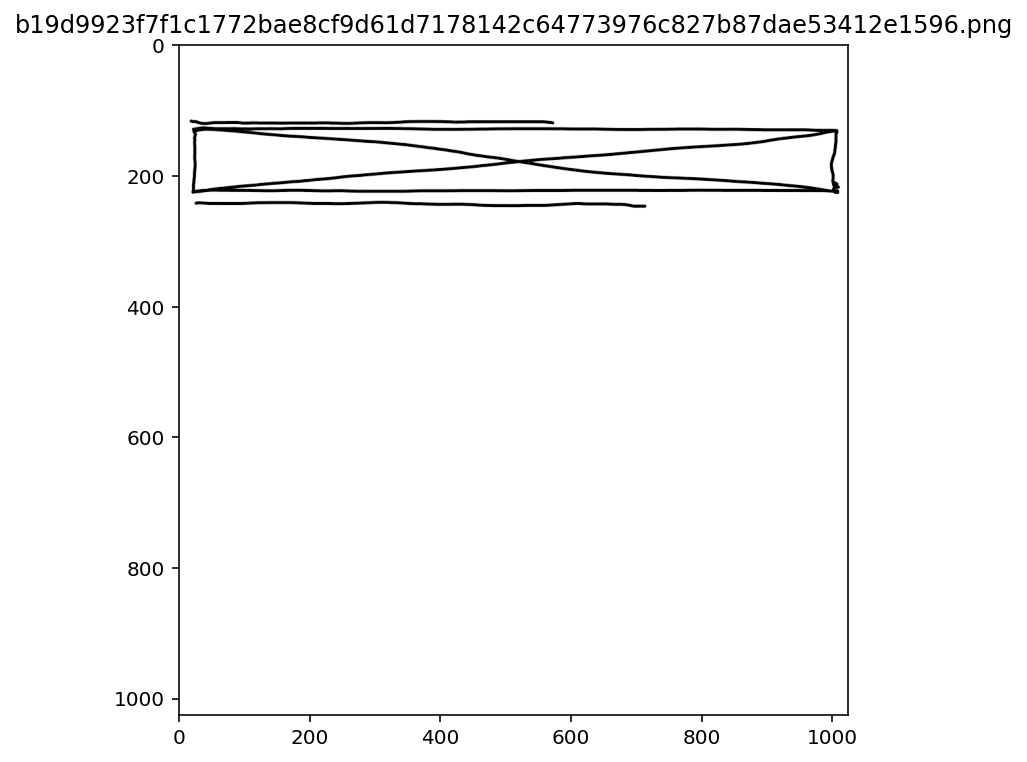

In [ ]:
for example in parsed_dataset.take(10):
  example_id = example['example_id'].numpy().decode()
  sketch_image = tf.io.decode_image(example['sketch/encoded'].numpy())

  pl.figure(figsize=(6, 10))
  pl.title(example_id)
  pl.imshow(sketch_image)
  pl.show()

## Download and read the full generated sketches datasets

The sizes of the compressed full datasets are:
* publaynet_generated_sketches.tgz - 24.6GB
* doclaynet_generated_sketches.tgz - 2.2GB
* slidevqa_generated_sketches.tgz - 1.1GB

To download the full datasets, uncomment and run the commands in the cell below.

In [ ]:
# # PubLayNet
# !wget -nc https://storage.mtls.cloud.google.com/sketch_to_layout_dataset/publaynet_generated_sketches.tgz
# !tar zxf publaynet_generated_sketches.tgz
# !ls publaynet_generated_sketches

# # DocLayNet
# !wget -nc https://storage.mtls.cloud.google.com/sketch_to_layout_dataset/doclaynet_generated_sketches.tgz
# !tar zxf doclaynet_generated_sketches.tgz
# !ls doclaynet_generated_sketches

# # SlideVQA
# !wget -nc https://storage.mtls.cloud.google.com/sketch_to_layout_dataset/slidevqa_generated_sketches.tgz
# !tar zxf slidevqa_generated_sketches.tgz
# !ls slidevqa_generated_sketches

The following cell contains example code of how to load the full datasets in `tf.data.Dataset` format.

In [ ]:
GENERATED_SKETCHES_ROOT_DIRS = {
    "publaynet": 'publaynet_generated_sketches',
    "doclaynet": 'doclaynet_generated_sketches',
    "slidevqa": 'slidevqa_generated_sketches',
}

def get_tf_dataset(dataset: str, split: str) -> tf.data.Dataset:
  """Returns a tf.data.Dataset for the given dataset and split.

  Args:
    dataset: The dataset for which to create the tf.data.Dataset. Must be one
      of: "publaynet", "doclaynet", "slidevqa".
    split: The split for which to create the tf.data.Dataset. Must be one of:
      "train", "val", "test".

  Returns:
    A tf.data.Dataset for the given dataset and split.
  """
  if dataset not in ['publaynet', 'doclaynet', 'slidevqa']:
    raise ValueError(f'Unsupported dataset: {dataset}')
  if split not in ['train', 'val', 'test']:
    raise ValueError(f'Unsupported split: {split}')

  root_dir = GENERATED_SKETCHES_ROOT_DIRS[dataset]

  raw_train_files = tf.data.Dataset.list_files(
      os.path.join(root_dir, f'{dataset}_{split}.tfrecord*'),
      shuffle=False,
  )
  raw_train_dataset = raw_train_files.flat_map(tf.data.TFRecordDataset)
  parsed_train_dataset = raw_train_dataset.map(_parse_function)
  return parsed_train_dataset


# # PubLayNet
# parsed_publaynet_train_dataset = get_tf_dataset('publaynet', 'train')
# parsed_publaynet_val_dataset = get_tf_dataset('publaynet', 'val')
# parsed_publaynet_test_dataset = get_tf_dataset('publaynet', 'test')


# # DocLayNet
# parsed_doclaynet_train_dataset = get_tf_dataset('doclaynet', 'train')
# parsed_doclaynet_val_dataset = get_tf_dataset('doclaynet', 'val')
# parsed_doclaynet_test_dataset = get_tf_dataset('doclaynet', 'test')

# # SlideVQA
# parsed_slidevqa_train_dataset = get_tf_dataset('slidevqa', 'train')
# parsed_slidevqa_val_dataset = get_tf_dataset('slidevqa', 'val')
# parsed_slidevqa_test_dataset = get_tf_dataset('slidevqa', 'test')